In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import sys
import json

from util.config_utils import load_yaml
from test import analyze_preds

****** 1000_run ******
CONSTRAINED
accuracy                  0.2237
top3_accuracy             0.4080
top5_accuracy             0.5775
macro_precision           0.1784
macro_recall              0.1049
micro_precision           0.2237
micro_recall              0.2237
f1_score                  0.0759
mean_average_precision    0.1464
mean_entropy              0.8800
UNCONSTRAINED
accuracy                  0.2254
top3_accuracy             0.4729
top5_accuracy             0.6146
macro_precision           0.1316
macro_recall              0.1095
micro_precision           0.2254
micro_recall              0.2254
f1_score                  0.1112
mean_average_precision    0.1033
mean_entropy              2.4467
****** 2000_run ******
CONSTRAINED
accuracy                  0.2331
top3_accuracy             0.4485
top5_accuracy             0.6578
macro_precision           0.0964
macro_recall              0.1221
micro_precision           0.2331
micro_recall              0.2331
f1_score                 

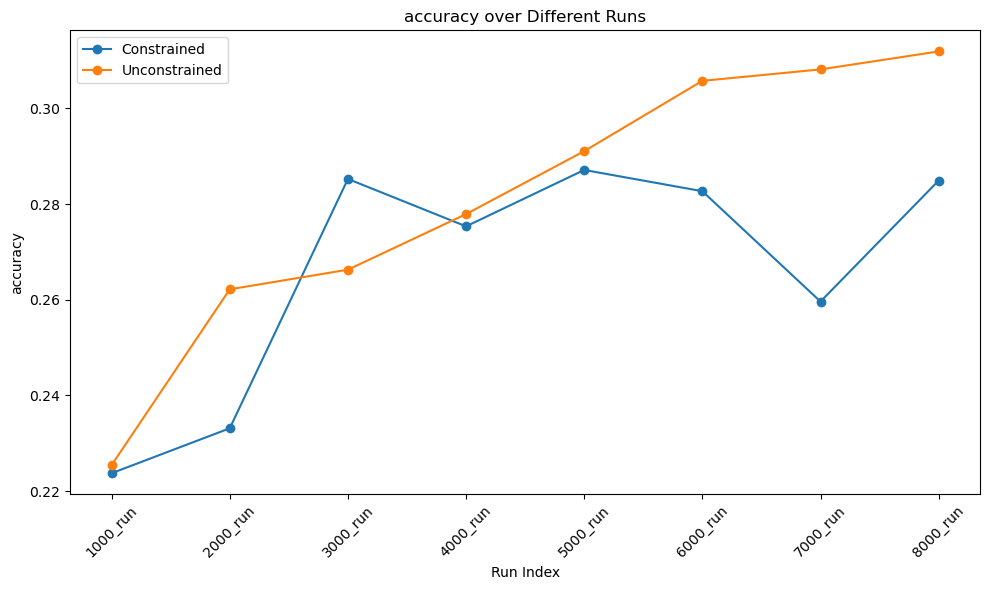

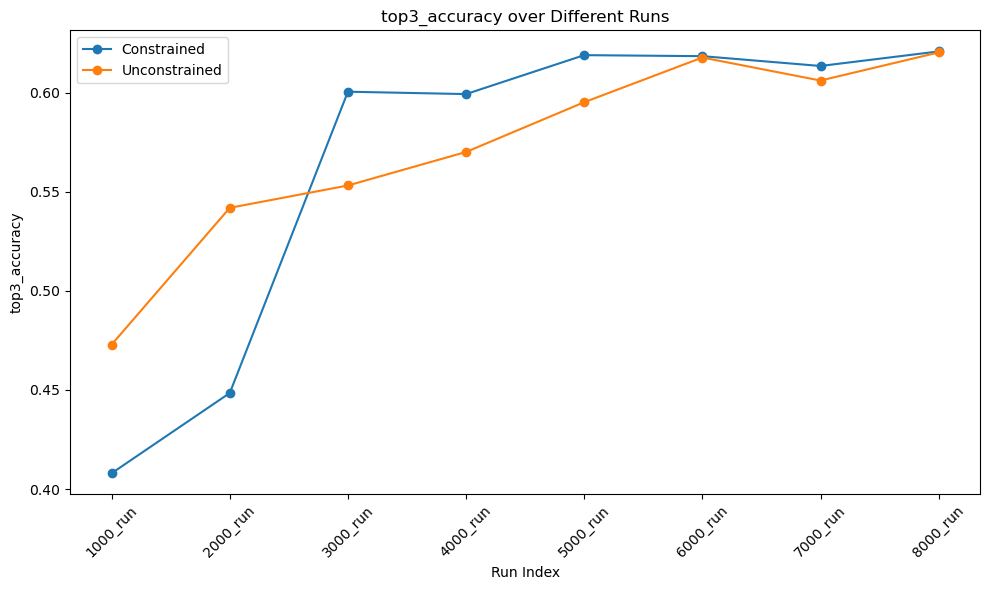

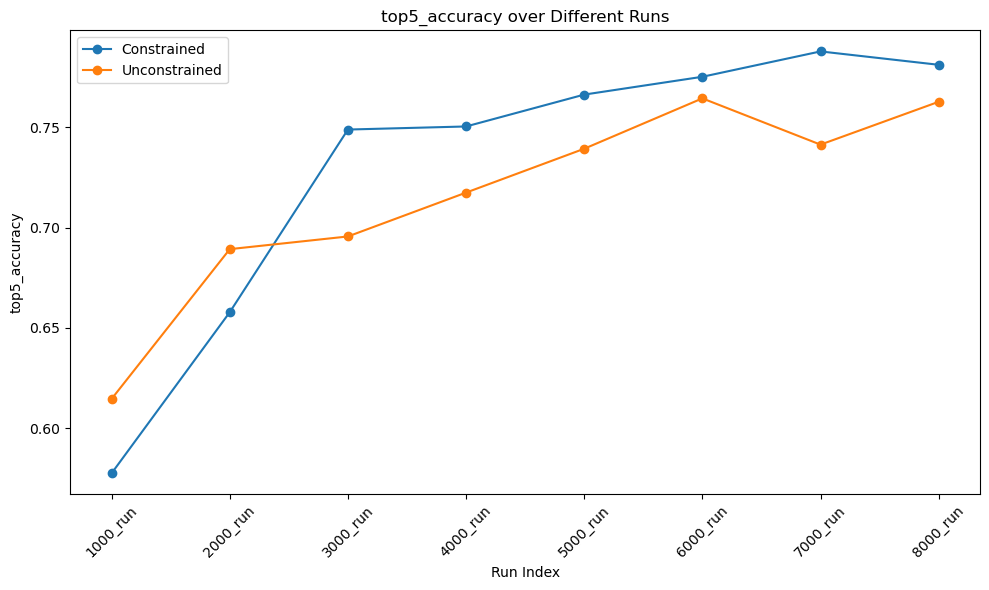

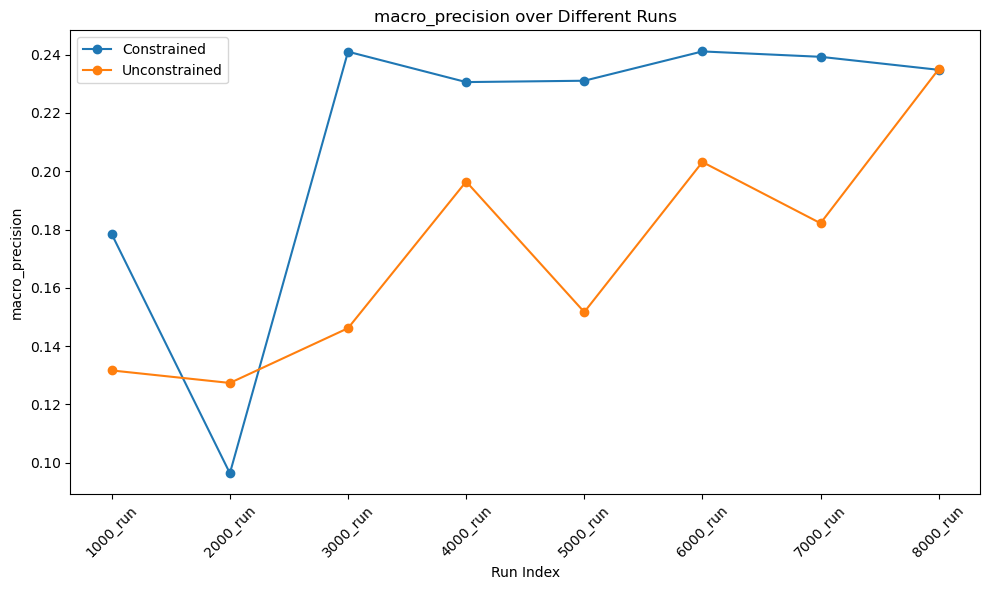

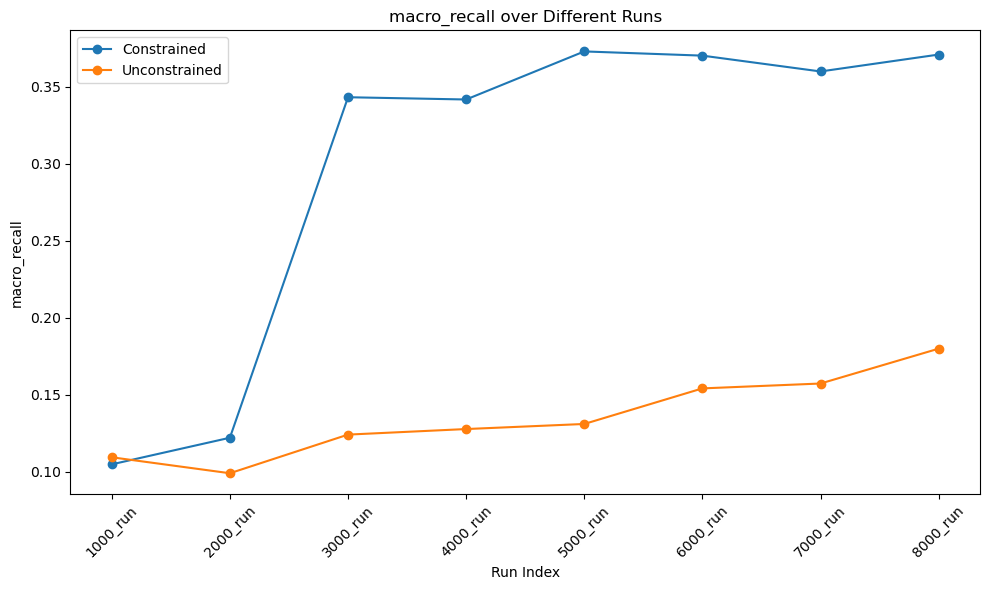

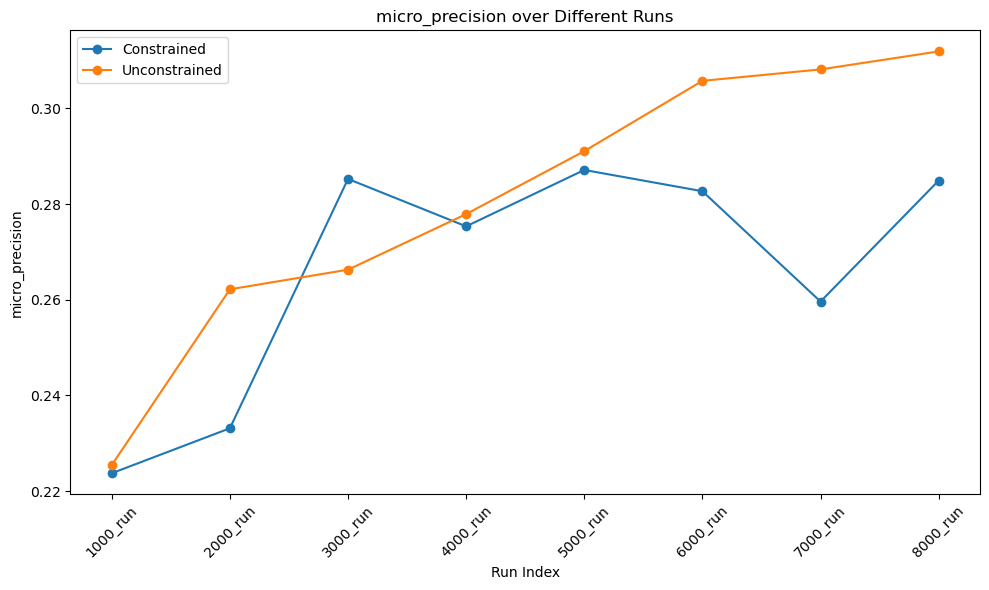

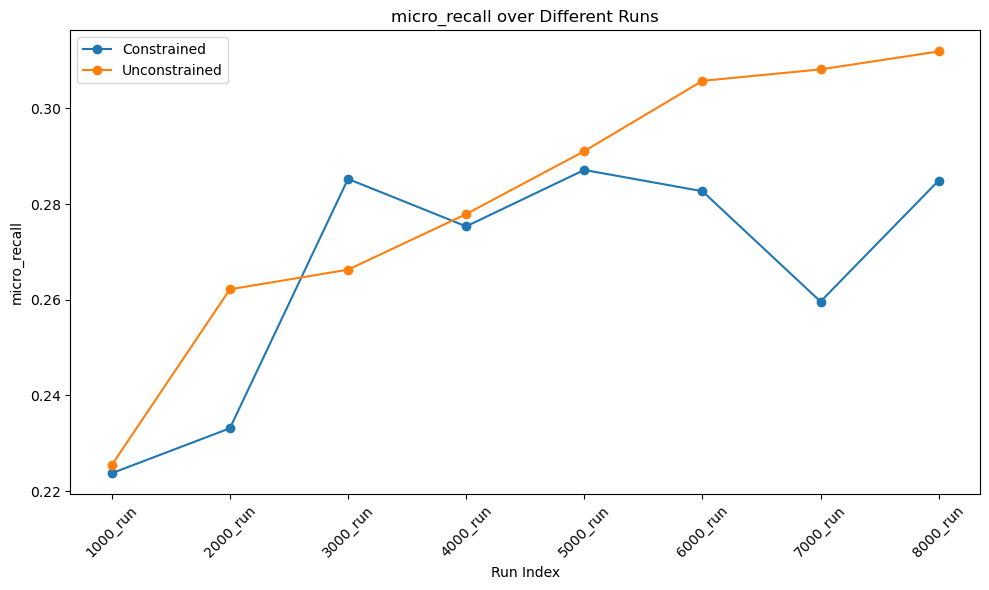

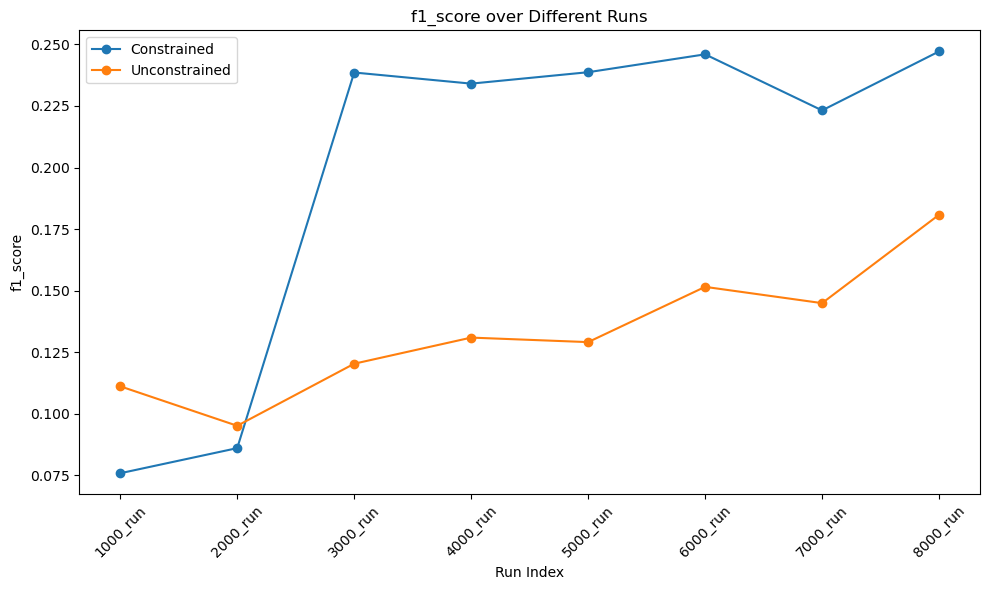

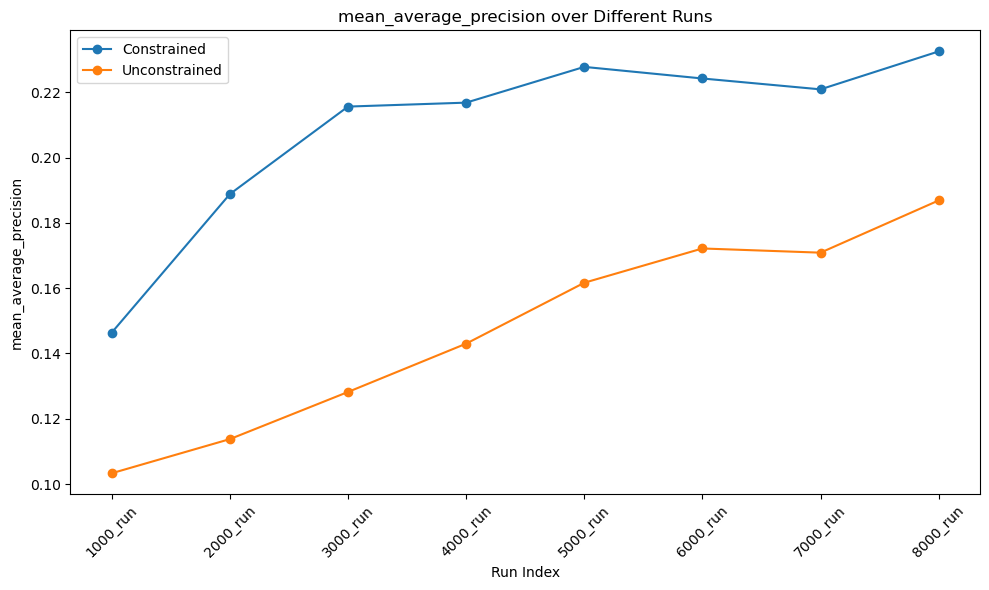

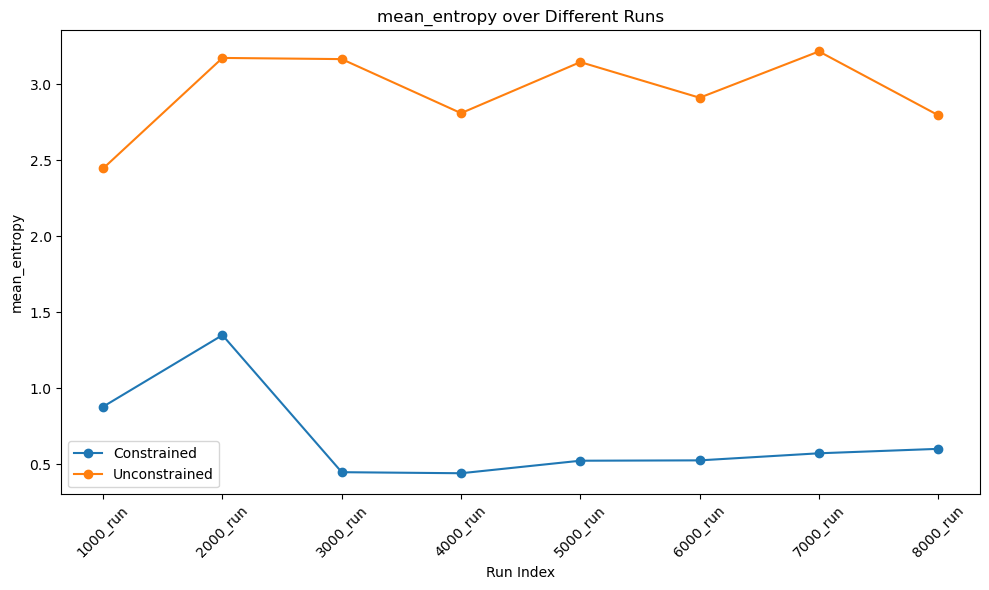

In [ ]:
paths = [
    ['1000_run', 'mild-data'],
    ['2000_run', 'rowdy-row'],
    ['3000_run', 'coffee-ton'],
    ['4000_run', 'spicy-cayenne'],
    ['5000_run', 'threaded-geometry'],
    ['6000_run', 'andante-cello'],
    ['7000_run', 'ash-decay'],
    ['8000_run', 'warped-mode']
]

constrained_metrics = []
unconstrained_metrics = []

for run_name, test_run_name in paths:
    cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
    print('******', run_name, '******')
    print('CONSTRAINED')
    constrained_metrics.append(analyze_preds(cfg, run_name, test_run_name, preds='constrained'))
    print('UNCONSTRAINED')
    unconstrained_metrics.append(analyze_preds(cfg, run_name, test_run_name, preds='unconstrained'))


# Assuming analyze_preds returns a dictionary of metrics
metric_names = constrained_metrics[0].keys()

# Plotting
for metric in metric_names:
    plt.figure(figsize=(10, 6))
    constrained_values = [metrics[metric] for metrics in constrained_metrics]
    unconstrained_values = [metrics[metric] for metrics in unconstrained_metrics]
    
    plt.plot(range(len(paths)), constrained_values, label='Constrained', marker='o')
    plt.plot(range(len(paths)), unconstrained_values, label='Unconstrained', marker='o')
    
    plt.title(f'{metric} over Different Runs')
    plt.xlabel('Run Index')
    plt.ylabel(metric)
    plt.xticks(ticks=range(len(paths)), labels=[run[0] for run in paths], rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
